# Hindsight: LEDGAR Employment Law CBA Experiment

## Concept Binding Accuracy on Legal Contract Provisions

**Domain**: Employment law (SEC-filed contracts)  
**Dataset**: [LEDGAR](https://github.com/dtuggener/LEDGAR_provision_classification) via [LexGLUE](https://huggingface.co/datasets/coastalcph/lex_glue) (CC license)  
**Task**: Classify legal provisions into confusable concept categories  

### Why LEDGAR?

LEDGAR contains ~80K real legal provisions from SEC filings, labeled across 100 categories.
We focus on **15 employment-relevant concepts** grouped into **6 confusable families**:

| Family | Concepts | Why Confusable |
|--------|----------|----------------|
| Termination Events | Death, Disability, Terminations | 25% of Disability provisions mention 'death' |
| Compensation | Base Salary, Benefits | Overlapping employee perks |
| Tax & Withholding | Tax Withholdings, Taxes, Withholdings | 94% of Withholdings mention 'tax' |
| Indemnity | Indemnifications, Indemnity | Near-synonyms, both say 'shall indemnify' |
| Equity | Vesting, Forfeitures | Inverse concepts, 37% of Forfeitures mention 'vesting' |
| Role | Employment, Duties, Positions | 66% of Positions mention 'employment' |

### Experiment Design

1. **Bundle Construction**: Create synthetic documents by bundling 15 provisions (one per concept)
2. **LLM Classification**: Ask the model to classify each provision into the correct concept
3. **CBA Scoring**: Measure whether the model binds each provision to the correct concept
4. **Delta = F1 - CBA**: Positive delta = model acknowledges provisions but misclassifies them

### Models
- Claude Haiku (claude-haiku-4-5-20251001)
- GPT-4o-mini

In [6]:
!pip install anthropic openai datasets pandas -q

import anthropic, openai, json, time, os, random, re
from datasets import load_dataset
from collections import defaultdict, Counter
from datetime import datetime
from google.colab import userdata


ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

print("Setup complete.")

Setup complete.


In [7]:
# Cell 2: Load LEDGAR dataset and build provision pools

ds = load_dataset("coastalcph/lex_glue", "ledgar")
label_names = ds['test'].features['label'].names
print(f"LEDGAR loaded: {len(label_names)} categories")
print(f"Splits: train={len(ds['train'])}, test={len(ds['test'])}, val={len(ds['validation'])}")

# 15 eval concepts in 6 confusable families
EVAL_CONCEPTS = [
    "Death", "Disability", "Terminations",          # termination_events
    "Base Salary", "Benefits",                       # compensation
    "Tax Withholdings", "Taxes", "Withholdings",     # tax_withholding
    "Indemnifications", "Indemnity",                 # indemnity
    "Vesting", "Forfeitures",                        # equity
    "Employment", "Duties", "Positions",             # role
]

# Build provision pool: collect all provisions for eval concepts across all splits
provision_pool = defaultdict(list)  # concept -> list of provision texts
MAX_PROVISION_LENGTH = 1500  # Cap long provisions

for split in ['train', 'test', 'validation']:
    for i in range(len(ds[split])):
        ex = ds[split][i]
        concept = label_names[ex['label']]
        if concept in EVAL_CONCEPTS:
            text = ex['text'].strip()
            if len(text) > MAX_PROVISION_LENGTH:
                text = text[:MAX_PROVISION_LENGTH] + "..."
            provision_pool[concept].append(text)

print(f"\nProvision pool sizes:")
for concept in EVAL_CONCEPTS:
    print(f"  {concept:<25} {len(provision_pool[concept]):>5} provisions")
print(f"\nTotal: {sum(len(v) for v in provision_pool.values())} provisions")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ledgar/train-00000-of-00001.parquet:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

ledgar/test-00000-of-00001.parquet:   0%|          | 0.00/3.31M [00:00<?, ?B/s]

ledgar/validation-00000-of-00001.parquet:   0%|          | 0.00/3.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

LEDGAR loaded: 100 categories
Splits: train=60000, test=10000, val=10000

Provision pool sizes:
  Death                       395 provisions
  Disability                  354 provisions
  Terminations               1423 provisions
  Base Salary                 882 provisions
  Benefits                    560 provisions
  Tax Withholdings            512 provisions
  Taxes                      1488 provisions
  Withholdings                711 provisions
  Indemnifications           1228 provisions
  Indemnity                   347 provisions
  Vesting                     621 provisions
  Forfeitures                 398 provisions
  Employment                  397 provisions
  Duties                      473 provisions
  Positions                   256 provisions

Total: 10045 provisions


In [8]:
# Cell 3: Ontology & Prompts

LEDGAR_ONTOLOGY = {
    "families": {
        "termination_events": ["Death", "Disability", "Terminations"],
        "compensation": ["Base Salary", "Benefits"],
        "tax_withholding": ["Tax Withholdings", "Taxes", "Withholdings"],
        "indemnity": ["Indemnifications", "Indemnity"],
        "equity": ["Vesting", "Forfeitures"],
        "role": ["Employment", "Duties", "Positions"],
    }
}

# Build concept_to_family lookup
concept_to_family = {}
for family, concepts in LEDGAR_ONTOLOGY["families"].items():
    for c in concepts:
        concept_to_family[c] = family

ontology = {
    "families": LEDGAR_ONTOLOGY["families"],
    "concept_to_family": concept_to_family,
}

SYSTEM_PROMPT = """You are a legal document classification system. Given a set of numbered legal provisions from a contract, classify each provision into exactly one of the following categories.

Categories:
- Death: Provisions triggered by death of employee/participant
- Disability: Provisions triggered by disability/incapacity of employee
- Terminations: General termination provisions (not death or disability specific)
- Base Salary: Provisions defining base salary or base compensation amount
- Benefits: Provisions about employee benefits (health, retirement, PTO, perquisites)
- Tax Withholdings: Provisions about withholding taxes from compensation or awards
- Taxes: Provisions about tax obligations, tax treatment, or tax gross-up
- Withholdings: Provisions about deducting/withholding amounts from compensation
- Indemnifications: Provisions granting indemnification rights or protections
- Indemnity: Provisions imposing indemnity obligations (hold-harmless)
- Vesting: Provisions about equity/award vesting schedules or conditions
- Forfeitures: Provisions about equity/award forfeiture upon certain events
- Employment: Provisions about the employment relationship and engagement terms
- Duties: Provisions about job duties, responsibilities, and reporting
- Positions: Provisions about job title, position, and role description

Return a JSON array where each item has:
- "clause": the provision number (integer)
- "concept": the category name from the list above (exact string match)

Rules:
- Classify EVERY provision — do not skip any
- Each provision gets exactly one category
- Use the exact category names listed above"""

print(f"Ontology: {len(LEDGAR_ONTOLOGY['families'])} families, {len(EVAL_CONCEPTS)} concepts")
print(f"System prompt: {len(SYSTEM_PROMPT)} chars")

Ontology: 6 families, 15 concepts
System prompt: 1622 chars


In [9]:
# Cell 4: Bundle Construction

N_BUNDLES = 50
random.seed(42)

# Shuffle provision pools
shuffled_pools = {}
for concept in EVAL_CONCEPTS:
    pool = provision_pool[concept].copy()
    random.shuffle(pool)
    shuffled_pools[concept] = pool

# Track usage index per concept (cycle if pool exhausted)
pool_idx = {c: 0 for c in EVAL_CONCEPTS}

bundles = []
for bundle_i in range(N_BUNDLES):
    # Pick one provision per concept
    provisions = []
    gt_mapping = {}  # clause_num -> concept

    for concept in EVAL_CONCEPTS:
        idx = pool_idx[concept] % len(shuffled_pools[concept])
        text = shuffled_pools[concept][idx]
        pool_idx[concept] += 1
        provisions.append((concept, text))

    # Shuffle provisions within bundle so concept order doesn't give hints
    random.shuffle(provisions)

    # Build numbered document and GT mapping
    doc_parts = []
    for clause_num, (concept, text) in enumerate(provisions, 1):
        doc_parts.append(f"Provision {clause_num}:\n{text}")
        gt_mapping[clause_num] = concept

    bundle_text = "\n\n".join(doc_parts)

    bundles.append({
        "bundle_id": bundle_i,
        "text": bundle_text,
        "gt_mapping": gt_mapping,  # {clause_num: concept}
        "n_clauses": len(provisions),
        "text_length": len(bundle_text),
    })

# Stats
lengths = [b["text_length"] for b in bundles]
print(f"Created {len(bundles)} bundles")
print(f"Clauses per bundle: {bundles[0]['n_clauses']}")
print(f"Bundle text length: min={min(lengths)}, median={sorted(lengths)[len(lengths)//2]}, max={max(lengths)}")
print(f"Approx tokens per bundle: {sorted(lengths)[len(lengths)//2] // 4}")
print(f"\nTotal classifications: {sum(b['n_clauses'] for b in bundles)}")

# Show sample bundle (first 3 clauses)
print(f"\n--- Sample bundle (first 3 clauses) ---")
sample = bundles[0]
for clause_num in range(1, 4):
    concept = sample['gt_mapping'][clause_num]
    print(f"  Clause {clause_num} → GT: {concept}")

Created 50 bundles
Clauses per bundle: 15
Bundle text length: min=7495, median=10589, max=13386
Approx tokens per bundle: 2647

Total classifications: 750

--- Sample bundle (first 3 clauses) ---
  Clause 1 → GT: Terminations
  Clause 2 → GT: Taxes
  Clause 3 → GT: Disability


In [10]:
# Cell 5: Scoring Functions

def cba_strict(predicted_concept, ground_truth_concept):
    """Binary concept-binding accuracy: 1.0 if match, 0.0 otherwise."""
    return 1.0 if predicted_concept == ground_truth_concept else 0.0


def cba_soft(predicted_concept, ground_truth_concept, ontology):
    """Partial-credit CBA: 1.0 exact, 0.5 same family, 0.0 otherwise."""
    if predicted_concept == ground_truth_concept:
        return 1.0
    c2f = ontology.get("concept_to_family", {})
    gt_family = c2f.get(ground_truth_concept)
    pred_family = c2f.get(predicted_concept)
    if gt_family is not None and gt_family == pred_family:
        return 0.5
    return 0.0


def score_bundle(gt_mapping, pred_mapping, ontology):
    """Score a bundle of clause classifications.

    gt_mapping: {clause_num: concept} e.g., {1: 'Death', 2: 'Disability'}
    pred_mapping: {clause_num: concept} e.g., {1: 'Disability', 2: 'Death'}

    Scoring:
    - field_recall: Did the model produce a classification for this clause? (extraction coverage)
    - cba_strict: Did it assign the correct concept? (binding accuracy)
    - delta = field_recall - cba_strict: Positive = misbinding (acknowledged but misclassified)
    """
    per_field = []
    misbindings = []

    for clause_num, gt_concept in gt_mapping.items():
        pred_concept = pred_mapping.get(clause_num)

        if pred_concept is None:
            # Model skipped this clause
            field_score = {
                "field_recall_contribution": 0.0,
                "cba_strict": 0.0,
                "cba_soft": 0.0,
                "is_misbinding": False,
                "gt_concept": gt_concept,
                "pred_concept": "__MISSING__",
                "clause_num": clause_num,
            }
        else:
            correct = (pred_concept == gt_concept)
            strict = 1.0 if correct else 0.0
            soft = cba_soft(pred_concept, gt_concept, ontology)

            field_score = {
                "field_recall_contribution": 1.0,  # Model acknowledged the clause
                "cba_strict": strict,
                "cba_soft": soft,
                "is_misbinding": not correct,
                "gt_concept": gt_concept,
                "pred_concept": pred_concept,
                "clause_num": clause_num,
            }

            if not correct:
                misbindings.append({
                    "gt_concept": gt_concept,
                    "pred_concept": pred_concept,
                    "clause_num": clause_num,
                })

        per_field.append(field_score)

    n = len(per_field)
    if n == 0:
        return {
            "field_recall": 0.0, "cba_strict": 0.0, "cba_soft": 0.0,
            "delta": 0.0, "n_fields": 0, "n_misbindings": 0,
            "misbindings": [], "per_field": [],
        }

    field_recall = sum(f["field_recall_contribution"] for f in per_field) / n
    cba_s = sum(f["cba_strict"] for f in per_field) / n
    cba_so = sum(f["cba_soft"] for f in per_field) / n

    return {
        "field_recall": round(field_recall, 6),
        "cba_strict": round(cba_s, 6),
        "cba_soft": round(cba_so, 6),
        "delta": round(field_recall - cba_s, 6),
        "n_fields": n,
        "n_misbindings": len(misbindings),
        "misbindings": misbindings,
        "per_field": per_field,
    }


def build_confusion_matrix(scored_bundles):
    """Build NxN concept confusion matrix from scored bundles."""
    concept_set = set(EVAL_CONCEPTS)
    pair_counts = defaultdict(int)

    for bundle in scored_bundles:
        for field in bundle.get("per_field", []):
            gt_c = field["gt_concept"]
            pred_c = field["pred_concept"]
            concept_set.add(gt_c)
            if pred_c != "__MISSING__":
                concept_set.add(pred_c)
            pair_counts[(gt_c, pred_c)] += 1

    concepts = sorted(concept_set)
    idx = {c: i for i, c in enumerate(concepts)}
    n = len(concepts)

    matrix = [[0] * n for _ in range(n)]
    for (gt_c, pred_c), count in pair_counts.items():
        if gt_c in idx and pred_c in idx:
            matrix[idx[gt_c]][idx[pred_c]] += count

    families = {c: concept_to_family.get(c, "unknown") for c in concepts}
    return {"matrix": matrix, "concepts": concepts, "families": families}


def top_confusions(matrix_data, n=10):
    """Return top N most frequent off-diagonal confusions."""
    concepts = matrix_data["concepts"]
    matrix = matrix_data["matrix"]
    confusions = []
    for i, gt_c in enumerate(concepts):
        for j, pred_c in enumerate(concepts):
            if i != j and matrix[i][j] > 0:
                confusions.append((gt_c, pred_c, matrix[i][j]))
    confusions.sort(key=lambda x: x[2], reverse=True)
    return confusions[:n]


# Sanity check: test scoring with a known swap
test_gt = {1: "Death", 2: "Disability", 3: "Terminations"}
test_pred = {1: "Disability", 2: "Death", 3: "Terminations"}  # Swapped 1 and 2
test_result = score_bundle(test_gt, test_pred, ontology)
assert test_result["field_recall"] == 1.0, "All clauses classified"
assert test_result["cba_strict"] < 1.0, "Two are wrong"
assert test_result["n_misbindings"] == 2, "Two misbindings"
assert test_result["delta"] > 0, "Positive delta"
print(f"Sanity check passed: F1={test_result['field_recall']}, CBA={test_result['cba_strict']:.3f}, "
      f"delta={test_result['delta']:.3f}, misbindings={test_result['n_misbindings']}")

# Test CBA-soft (same family gets 0.5)
assert cba_soft("Death", "Disability", ontology) == 0.5, "Same family = 0.5"
assert cba_soft("Death", "Vesting", ontology) == 0.0, "Different family = 0.0"
print("CBA-soft family scoring verified.")

Sanity check passed: F1=1.0, CBA=0.333, delta=0.667, misbindings=2
CBA-soft family scoring verified.


In [11]:
# Cell 6: LLM Call Functions

MAX_RETRIES = 5
BASE_DELAY = 2


def _parse_json(raw):
    """Strip markdown fences and parse JSON."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


def _retry_with_backoff(fn, max_retries=MAX_RETRIES, base_delay=BASE_DELAY):
    """Call fn() with exponential backoff on rate-limit (429) errors."""
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            is_rate_limit = "429" in str(e) or "rate_limit" in str(e).lower()
            if attempt < max_retries - 1:
                delay = base_delay * (2 ** attempt) if is_rate_limit else base_delay
                label = "Rate limited" if is_rate_limit else "Error"
                print(f"    {label}, retry {attempt+1}/{max_retries-1} in {delay}s: {type(e).__name__}")
                time.sleep(delay)
            else:
                raise


def _array_to_pred_mapping(stage2_array):
    """Convert LLM output array to {clause_num: concept} dict.

    First mapping per clause wins.
    """
    pred_mapping = {}
    for item in stage2_array:
        if not isinstance(item, dict):
            continue
        clause = item.get("clause") or item.get("clause_number") or item.get("provision")
        concept = item.get("concept", "")
        if clause is not None and concept:
            clause_num = int(clause)
            if clause_num not in pred_mapping:
                pred_mapping[clause_num] = concept
    return pred_mapping


def classify_anthropic(bundle_text, model):
    """Classify provisions using Anthropic API."""
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    def _call():
        message = client.messages.create(
            model=model,
            max_tokens=1024,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": f"Classify each provision below:\n\n{bundle_text}"}]
        )
        return _parse_json(message.content[0].text)

    return _retry_with_backoff(_call)


def classify_openai(bundle_text, model):
    """Classify provisions using OpenAI API."""
    client = openai.OpenAI(api_key=OPENAI_API_KEY)

    def _call():
        response = client.chat.completions.create(
            model=model,
            max_tokens=1024,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify each provision below:\n\n{bundle_text}"}
            ]
        )
        return _parse_json(response.choices[0].message.content)

    return _retry_with_backoff(_call)


def classify_bundle(bundle_text, model, provider):
    """Classify a bundle of provisions. Returns (raw_array, pred_mapping)."""
    if provider == "anthropic":
        raw_array = classify_anthropic(bundle_text, model)
    else:
        raw_array = classify_openai(bundle_text, model)
    pred_mapping = _array_to_pred_mapping(raw_array)
    return raw_array, pred_mapping


print("LLM call functions ready.")

LLM call functions ready.


In [12]:
# Cell 7: Run Loop

MODELS = {
    "haiku": {"provider": "anthropic", "model_id": "claude-haiku-4-5-20251001"},
    "gpt4o-mini": {"provider": "openai", "model_id": "gpt-4o-mini"},
}

RATE_DELAYS = {"anthropic": 2, "openai": 3}

experiments = {}

for model_name, model_cfg in MODELS.items():
    config_key = model_name
    print(f"\n{'='*60}")
    print(f"Running: {config_key} — {model_cfg['model_id']}")
    print(f"{'='*60}")

    provider = model_cfg["provider"]
    model_id = model_cfg["model_id"]
    rate_delay = RATE_DELAYS[provider]

    bundle_results = []
    all_misbindings = []
    errors = []
    raw_outputs = []

    for i, bundle in enumerate(bundles):
        bundle_id = f"bundle_{bundle['bundle_id']:03d}"

        try:
            raw_array, pred_mapping = classify_bundle(
                bundle["text"], model_id, provider
            )

            raw_outputs.append({
                "bundle_id": bundle_id,
                "n_predictions": len(pred_mapping),
                "raw_array": raw_array,
            })

            # Score
            bundle_score = score_bundle(bundle["gt_mapping"], pred_mapping, ontology)
            bundle_score["bundle_id"] = bundle_id
            bundle_score["predictions"] = pred_mapping
            bundle_score["gt"] = bundle["gt_mapping"]
            bundle_results.append(bundle_score)

            # Track misbindings
            for mb in bundle_score["misbindings"]:
                mb["bundle_id"] = bundle_id
                mb["model"] = model_name
                all_misbindings.append(mb)

        except Exception as e:
            print(f"  ERROR on {bundle_id}: {e}")
            errors.append({"bundle_id": bundle_id, "error": str(e)})

        if (i + 1) % 10 == 0:
            if bundle_results:
                avg_f1 = sum(d["field_recall"] for d in bundle_results) / len(bundle_results)
                avg_cba = sum(d["cba_strict"] for d in bundle_results) / len(bundle_results)
                avg_delta = sum(d["delta"] for d in bundle_results) / len(bundle_results)
                print(f"  [{i+1}/{len(bundles)}] F1={avg_f1:.3f}, CBA={avg_cba:.3f}, "
                      f"delta={avg_delta:.3f}, misbindings={len(all_misbindings)}")

        time.sleep(rate_delay)

    # Aggregate
    n_docs = len(bundle_results)
    if n_docs > 0:
        corpus_f1 = sum(d["field_recall"] for d in bundle_results) / n_docs
        corpus_cba_strict = sum(d["cba_strict"] for d in bundle_results) / n_docs
        corpus_cba_soft = sum(d["cba_soft"] for d in bundle_results) / n_docs
        corpus_delta = sum(d["delta"] for d in bundle_results) / n_docs
    else:
        corpus_f1 = corpus_cba_strict = corpus_cba_soft = corpus_delta = 0.0

    experiments[config_key] = {
        "model_id": model_id,
        "model_name": model_name,
        "provider": provider,
        "field_recall": round(corpus_f1, 6),
        "cba_strict": round(corpus_cba_strict, 6),
        "cba_soft": round(corpus_cba_soft, 6),
        "delta": round(corpus_delta, 6),
        "n_bundles": n_docs,
        "total_misbindings": len(all_misbindings),
        "misbinding_log": all_misbindings,
        "per_bundle": bundle_results,
        "errors": errors,
        "raw_outputs": raw_outputs,
    }

    print(f"\n  DONE: F1={corpus_f1:.4f}, CBA-strict={corpus_cba_strict:.4f}, "
          f"CBA-soft={corpus_cba_soft:.4f}, delta={corpus_delta:.4f}, "
          f"misbindings={len(all_misbindings)}, errors={len(errors)}")

print(f"\n\nAll experiments complete. {len(experiments)} models run.")


Running: haiku — claude-haiku-4-5-20251001
  [10/50] F1=1.000, CBA=0.787, delta=0.213, misbindings=32
  [20/50] F1=1.000, CBA=0.790, delta=0.210, misbindings=63
  [30/50] F1=1.000, CBA=0.784, delta=0.216, misbindings=97
  [40/50] F1=1.000, CBA=0.788, delta=0.212, misbindings=127
  [50/50] F1=1.000, CBA=0.793, delta=0.207, misbindings=155

  DONE: F1=1.0000, CBA-strict=0.7933, CBA-soft=0.8647, delta=0.2067, misbindings=155, errors=0

Running: gpt4o-mini — gpt-4o-mini
  [10/50] F1=1.000, CBA=0.740, delta=0.260, misbindings=39
  [20/50] F1=0.997, CBA=0.767, delta=0.230, misbindings=69
  [30/50] F1=0.998, CBA=0.756, delta=0.242, misbindings=109
  [40/50] F1=0.998, CBA=0.742, delta=0.257, misbindings=154
  [50/50] F1=0.999, CBA=0.739, delta=0.260, misbindings=195

  DONE: F1=0.9987, CBA-strict=0.7387, CBA-soft=0.8407, delta=0.2600, misbindings=195, errors=0


All experiments complete. 2 models run.


In [13]:
# Cell 8: Results Dashboard

import pandas as pd

# --- Cross-model comparison ---
print("=" * 80)
print("CROSS-MODEL COMPARISON")
print("=" * 80)

comparison_rows = []
for config_key, results in experiments.items():
    comparison_rows.append({
        "Model": results["model_name"],
        "Field Recall": f"{results['field_recall']:.4f}",
        "CBA-strict": f"{results['cba_strict']:.4f}",
        "CBA-soft": f"{results['cba_soft']:.4f}",
        "Delta": f"{results['delta']:.4f}",
        "Misbindings": results["total_misbindings"],
        "Errors": len(results["errors"]),
    })
df_comparison = pd.DataFrame(comparison_rows)
print(df_comparison.to_string(index=False))

# --- Per-concept accuracy ---
print(f"\n{'='*80}")
print("PER-CONCEPT ACCURACY")
print("=" * 80)

for config_key, results in experiments.items():
    print(f"\n--- {config_key} ---")
    concept_stats = defaultdict(lambda: {"field_acc": [], "cba_strict": [], "cba_soft": [], "misbindings": 0})

    for bundle in results["per_bundle"]:
        for field in bundle["per_field"]:
            gt_c = field["gt_concept"]
            if gt_c in EVAL_CONCEPTS:
                concept_stats[gt_c]["field_acc"].append(field["field_recall_contribution"])
                concept_stats[gt_c]["cba_strict"].append(field["cba_strict"])
                concept_stats[gt_c]["cba_soft"].append(field["cba_soft"])
                if field["is_misbinding"]:
                    concept_stats[gt_c]["misbindings"] += 1

    concept_rows = []
    for concept in EVAL_CONCEPTS:
        stats = concept_stats[concept]
        n = len(stats["field_acc"])
        if n > 0:
            fa = sum(stats["field_acc"]) / n
            cs = sum(stats["cba_strict"]) / n
            soft = sum(stats["cba_soft"]) / n
            delta = fa - cs
            concept_rows.append({
                "Concept": concept,
                "Family": concept_to_family.get(concept, "?"),
                "N": n,
                "F1": f"{fa:.3f}",
                "CBA": f"{cs:.3f}",
                "CBA-soft": f"{soft:.3f}",
                "Delta": f"{delta:.3f}",
                "Misbindings": stats["misbindings"],
            })
        else:
            concept_rows.append({
                "Concept": concept, "Family": concept_to_family.get(concept, "?"),
                "N": 0, "F1": "N/A", "CBA": "N/A", "CBA-soft": "N/A",
                "Delta": "N/A", "Misbindings": 0,
            })

    df_concepts = pd.DataFrame(concept_rows)
    print(df_concepts.to_string(index=False))

# --- Misbinding confusion pairs ---
print(f"\n{'='*80}")
print("MISBINDING CONFUSION PAIRS")
print("=" * 80)

for config_key, results in experiments.items():
    print(f"\n--- {config_key} ---")
    pair_counter = Counter()
    for mb in results["misbinding_log"]:
        pair_counter[(mb["gt_concept"], mb["pred_concept"])] += 1

    if pair_counter:
        pair_rows = []
        for (gt_c, pred_c), count in pair_counter.most_common(15):
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            pair_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_pairs = pd.DataFrame(pair_rows)
        print(df_pairs.to_string(index=False))
    else:
        print("  No misbindings detected.")

CROSS-MODEL COMPARISON
     Model Field F1 CBA-strict CBA-soft  Delta  Misbindings  Errors
     haiku   1.0000     0.7933   0.8647 0.2067          155       0
gpt4o-mini   0.9987     0.7387   0.8407 0.2600          195       0

PER-CONCEPT ACCURACY

--- haiku ---
         Concept             Family  N    F1   CBA CBA-soft Delta  Misbindings
           Death termination_events 50 1.000 0.920    0.930 0.080            4
      Disability termination_events 50 1.000 0.880    0.890 0.120            6
    Terminations termination_events 50 1.000 0.820    0.830 0.180            9
     Base Salary       compensation 50 1.000 0.980    0.980 0.020            1
        Benefits       compensation 50 1.000 0.640    0.670 0.360           18
Tax Withholdings    tax_withholding 50 1.000 0.860    0.920 0.140            7
           Taxes    tax_withholding 50 1.000 0.900    0.930 0.100            5
    Withholdings    tax_withholding 50 1.000 0.320    0.650 0.680           34
Indemnifications         


CONFUSION MATRIX — haiku


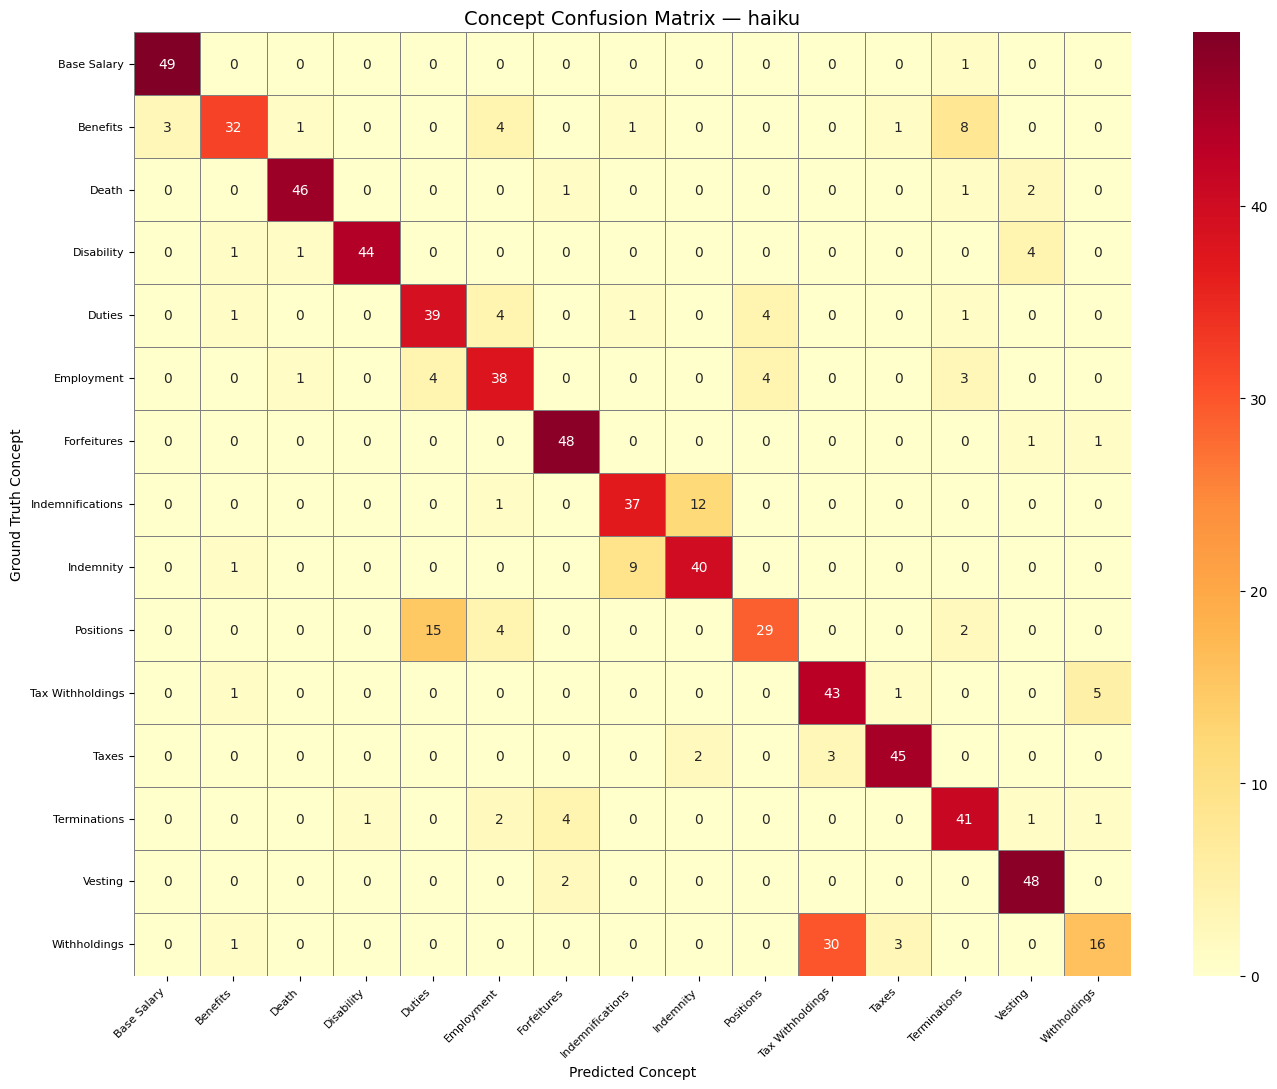


Top confusions (haiku):
      GT Concept     Pred Concept  Count Same Family?
    Withholdings Tax Withholdings     30          Yes
       Positions           Duties     15          Yes
Indemnifications        Indemnity     12          Yes
       Indemnity Indemnifications      9          Yes
        Benefits     Terminations      8           No
Tax Withholdings     Withholdings      5          Yes
        Benefits       Employment      4           No
      Disability          Vesting      4           No
          Duties       Employment      4          Yes
          Duties        Positions      4          Yes
      Employment           Duties      4          Yes
      Employment        Positions      4          Yes
       Positions       Employment      4          Yes
    Terminations      Forfeitures      4           No
        Benefits      Base Salary      3          Yes

CONFUSION MATRIX — gpt4o-mini


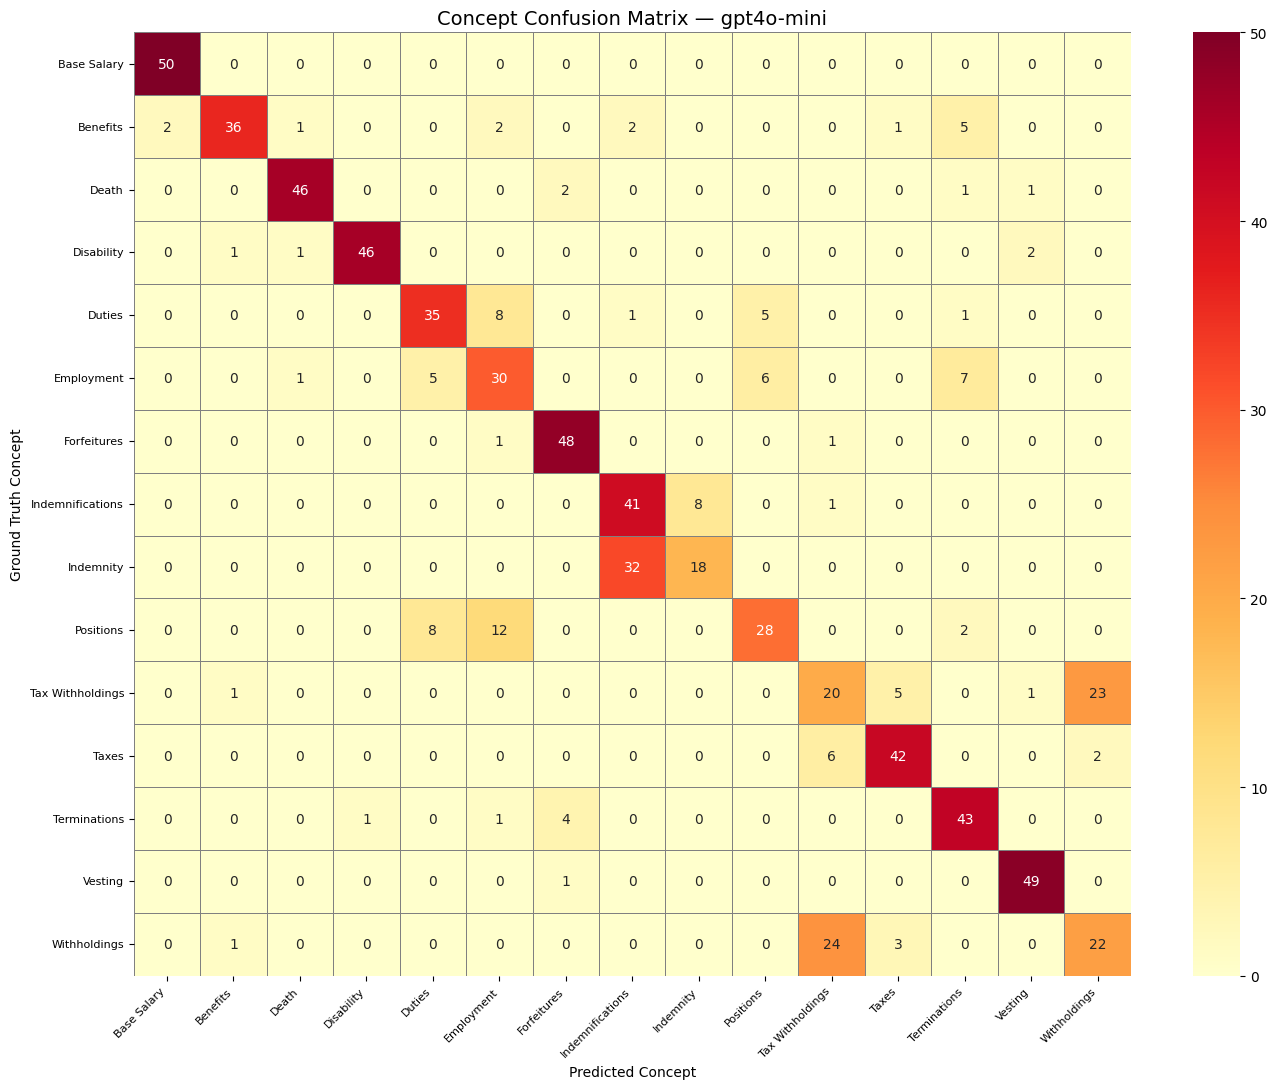


Top confusions (gpt4o-mini):
      GT Concept     Pred Concept  Count Same Family?
       Indemnity Indemnifications     32          Yes
    Withholdings Tax Withholdings     24          Yes
Tax Withholdings     Withholdings     23          Yes
       Positions       Employment     12          Yes
          Duties       Employment      8          Yes
Indemnifications        Indemnity      8          Yes
       Positions           Duties      8          Yes
      Employment     Terminations      7           No
      Employment        Positions      6          Yes
           Taxes Tax Withholdings      6          Yes
        Benefits     Terminations      5           No
          Duties        Positions      5          Yes
      Employment           Duties      5          Yes
Tax Withholdings            Taxes      5          Yes
    Terminations      Forfeitures      4           No

EXPECTED CONFUSION PAIRS — Cross-model summary
              GT             Pred  haiku  gpt4o-mini
     

In [14]:
# Cell 9: Confusion Matrix

import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOT = True
except ImportError:
    HAS_PLOT = False

for config_key, results in experiments.items():
    print(f"\n{'='*60}")
    print(f"CONFUSION MATRIX — {config_key}")
    print(f"{'='*60}")

    scored_bundles = results["per_bundle"]
    cm_data = build_confusion_matrix(scored_bundles)

    # Filter to eval concepts
    eval_idx = [i for i, c in enumerate(cm_data["concepts"]) if c in EVAL_CONCEPTS]
    eval_concepts_sorted = [cm_data["concepts"][i] for i in eval_idx]
    matrix_np = np.array(cm_data["matrix"])
    filtered_matrix = matrix_np[np.ix_(eval_idx, eval_idx)]

    df_cm = pd.DataFrame(
        filtered_matrix,
        index=eval_concepts_sorted,
        columns=eval_concepts_sorted
    )

    if HAS_PLOT:
        fig, ax = plt.subplots(figsize=(14, 11))
        sns.heatmap(
            df_cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, linecolor="gray",
            xticklabels=True, yticklabels=True,
        )
        ax.set_title(f"Concept Confusion Matrix — {config_key}", fontsize=14)
        ax.set_xlabel("Predicted Concept")
        ax.set_ylabel("Ground Truth Concept")
        plt.xticks(rotation=45, ha="right", fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print(df_cm.to_string())

    # Top confusions
    print(f"\nTop confusions ({config_key}):")
    top = top_confusions(cm_data, n=15)
    if top:
        top_rows = []
        for gt_c, pred_c, count in top:
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            top_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_top = pd.DataFrame(top_rows)
        print(df_top.to_string(index=False))
    else:
        print("  No off-diagonal confusions.")

# --- Expected confusion pairs summary ---
print(f"\n{'='*60}")
print("EXPECTED CONFUSION PAIRS — Cross-model summary")
print(f"{'='*60}")

expected_pairs = [
    ("Death", "Disability"),
    ("Disability", "Death"),
    ("Death", "Terminations"),
    ("Disability", "Terminations"),
    ("Terminations", "Death"),
    ("Terminations", "Disability"),
    ("Tax Withholdings", "Withholdings"),
    ("Withholdings", "Tax Withholdings"),
    ("Tax Withholdings", "Taxes"),
    ("Taxes", "Tax Withholdings"),
    ("Indemnifications", "Indemnity"),
    ("Indemnity", "Indemnifications"),
    ("Vesting", "Forfeitures"),
    ("Forfeitures", "Vesting"),
    ("Employment", "Duties"),
    ("Employment", "Positions"),
    ("Duties", "Positions"),
    ("Positions", "Duties"),
]

pair_summary_rows = []
for gt_c, pred_c in expected_pairs:
    row = {"GT": gt_c, "Pred": pred_c}
    for config_key, results in experiments.items():
        count = sum(1 for mb in results["misbinding_log"]
                    if mb["gt_concept"] == gt_c and mb["pred_concept"] == pred_c)
        row[config_key] = count
    pair_summary_rows.append(row)

df_expected = pd.DataFrame(pair_summary_rows)
print(df_expected.to_string(index=False))

In [15]:
# Cell 10: Export

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Collect all misbindings
all_misbinding_log = []
for config_key, results in experiments.items():
    all_misbinding_log.extend(results["misbinding_log"])

# Combined confusion matrix
all_scored_bundles = []
for config_key, results in experiments.items():
    all_scored_bundles.extend(results["per_bundle"])
combined_cm = build_confusion_matrix(all_scored_bundles)

# Export
export_results = {
    "experiment": "hindsight_ledgar_cba",
    "dataset": "coastalcph/lex_glue (LEDGAR config)",
    "domain": "employment_law",
    "scoring": "direct_classification_cba",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "description": (
        "Employment law concept binding on LEDGAR provisions. "
        "Bundles of 15 provisions from confusable families. "
        "LLM classifies each provision; CBA measures binding accuracy."
    ),
    "n_bundles": len(bundles),
    "clauses_per_bundle": bundles[0]["n_clauses"],
    "total_classifications": sum(b["n_clauses"] for b in bundles),
    "eval_concepts": EVAL_CONCEPTS,
    "ontology": LEDGAR_ONTOLOGY,
    "models": {
        model_name: {"model_id": cfg["model_id"], "provider": cfg["provider"]}
        for model_name, cfg in MODELS.items()
    },
    "results": {
        config_key: {
            "model": results["model_name"],
            "field_recall": results["field_recall"],
            "cba_strict": results["cba_strict"],
            "cba_soft": results["cba_soft"],
            "delta": results["delta"],
            "n_bundles": results["n_bundles"],
            "total_misbindings": results["total_misbindings"],
            "errors": len(results["errors"]),
            "per_bundle_summary": [
                {
                    "bundle_id": d["bundle_id"],
                    "field_recall": d["field_recall"],
                    "cba_strict": d["cba_strict"],
                    "cba_soft": d["cba_soft"],
                    "delta": d["delta"],
                    "n_misbindings": d["n_misbindings"],
                    "predictions": {str(k): v for k, v in d["predictions"].items()},
                    "gt": {str(k): v for k, v in d["gt"].items()},
                }
                for d in results["per_bundle"]
            ],
        }
        for config_key, results in experiments.items()
    },
    "raw_output_samples": {
        config_key: results["raw_outputs"][:5]
        for config_key, results in experiments.items()
    },
    "misbinding_log": all_misbinding_log,
    "confusion_matrix": {
        "concepts": combined_cm["concepts"],
        "matrix": combined_cm["matrix"],
        "families": combined_cm["families"],
    },
}

output_path = os.path.join(RESULTS_DIR, "hindsight_ledgar_cba_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(export_results, f, indent=2, default=str)

print(f"Results exported to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

# Final summary
print(f"\n{'='*70}")
print("EXPERIMENT SUMMARY — LEDGAR CBA (Employment Law)")
print(f"{'='*70}")
print(f"Dataset: LEDGAR (SEC-filed contract provisions)")
print(f"Bundles: {len(bundles)} x {bundles[0]['n_clauses']} clauses = {sum(b['n_clauses'] for b in bundles)} total")
print(f"Concepts: {len(EVAL_CONCEPTS)} in {len(LEDGAR_ONTOLOGY['families'])} families")

for config_key, results in experiments.items():
    print(f"\n{config_key}:")
    print(f"  Field Recall:       {results['field_recall']:.4f}")
    print(f"  CBA-strict:     {results['cba_strict']:.4f}")
    print(f"  CBA-soft:       {results['cba_soft']:.4f}")
    print(f"  Delta (F1-CBA): {results['delta']:.4f}")
    print(f"  Misbindings:    {results['total_misbindings']}")

total_misbindings = sum(r["total_misbindings"] for r in experiments.values())
print(f"\nTotal misbindings across all models: {total_misbindings}")

Results exported to: /content/../results/hindsight_ledgar_cba_results.json
File size: 195.7 KB

EXPERIMENT SUMMARY — LEDGAR CBA (Employment Law)
Dataset: LEDGAR (SEC-filed contract provisions)
Bundles: 50 x 15 clauses = 750 total
Concepts: 15 in 6 families

haiku:
  Field F1:       1.0000
  CBA-strict:     0.7933
  CBA-soft:       0.8647
  Delta (F1-CBA): 0.2067
  Misbindings:    155

gpt4o-mini:
  Field F1:       0.9987
  CBA-strict:     0.7387
  CBA-soft:       0.8407
  Delta (F1-CBA): 0.2600
  Misbindings:    195

Total misbindings across all models: 350
